# Sistema de Detección de Intrusiones — NSL-KDD

**Universidad Internacional del Ecuador — UIDE**
Ingeniería en Sistemas | Big Data



*   **Integrante:** Andres Quisilema
*   **Entregable 2**
*   **Fecha:** Mayo 2026








## 1. Librerías

In [ ]:
!pip install kagglehub -q

import kagglehub, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import os, warnings
warnings.filterwarnings('ignore')
print("Librerías listas.")


Librerías listas.


## 2. Extracción de Datos — API de Kaggle

Los datos se descargan directamente desde la API oficial de Kaggle usando `kagglehub`. Para autenticarse hay que configurar el token en la variable de entorno antes de ejecutar la descarga.


In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_3c76467bd1a04d0f7c6001e703981e69'

print("Token configurado.")


Token configurado.


In [ ]:
path = kagglehub.dataset_download("hassan06/nslkdd")
print("Dataset descargado en:", path)
print("Archivos:", os.listdir(path))


Using Colab cache for faster access to the 'nslkdd' dataset.
Dataset descargado en: /kaggle/input/nslkdd
Archivos: ['KDDTest+.arff', 'KDDTest-21.arff', 'KDDTest1.jpg', 'KDDTrain+.txt', 'KDDTrain+_20Percent.txt', 'KDDTest-21.txt', 'KDDTest+.txt', 'KDDTrain+.arff', 'index.html', 'nsl-kdd', 'KDDTrain+_20Percent.arff', 'KDDTrain1.jpg']


In [ ]:
# Nombres de las 43 columnas del dataset
columnas = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]

df_train = pd.read_csv(os.path.join(path, 'KDDTrain+.txt'), header=None, names=columnas)
df_test  = pd.read_csv(os.path.join(path, 'KDDTest+.txt'),  header=None, names=columnas)

print(f"Registros de entrenamiento : {len(df_train):,}")
print(f"Registros de prueba        : {len(df_test):,}")
print(f"Variables por registro     : {df_train.shape[1]}")
print()
print("Vista previa:")
df_train.head(3)


Registros de entrenamiento : 125,973
Registros de prueba        : 22,544
Variables por registro     : 43

Vista previa:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


## 3. Limpieza y Preprocesamiento


In [ ]:
# Valores nulos
print("Valores nulos en entrenamiento:", df_train.isnull().sum().sum())
print("Valores nulos en prueba       :", df_test.isnull().sum().sum())

# Duplicados
print("Duplicados en entrenamiento   :", df_train.duplicated().sum())


Valores nulos en entrenamiento: 0
Valores nulos en prueba       : 0
Duplicados en entrenamiento   : 0


In [ ]:
# Etiqueta binaria: 0 = normal, 1 = ataque
df_train['label_binario'] = df_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['label_binario']  = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

conteo = df_train['label_binario'].value_counts()
print(f"Normal (0): {conteo[0]:,}  |  Ataque (1): {conteo[1]:,}")


Normal (0): 67,343  |  Ataque (1): 58,630


In [ ]:
# Encoding de variables categóricas (texto → número)
le = LabelEncoder()
for col in ['protocol_type', 'service', 'flag']:
    le.fit(pd.concat([df_train[col], df_test[col]]))
    df_train[col] = le.transform(df_train[col])
    df_test[col]  = le.transform(df_test[col])



In [ ]:
# Separacion de features y etiqueta
features = [c for c in df_train.columns if c not in ['label','label_binario','difficulty_level']]

X_train = df_train[features]
y_train = df_train['label_binario']
X_test  = df_test[features]
y_test  = df_test['label_binario']

# Estandarización
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


X_train: (125973, 41)  |  X_test: (22544, 41)


### Exploración visual

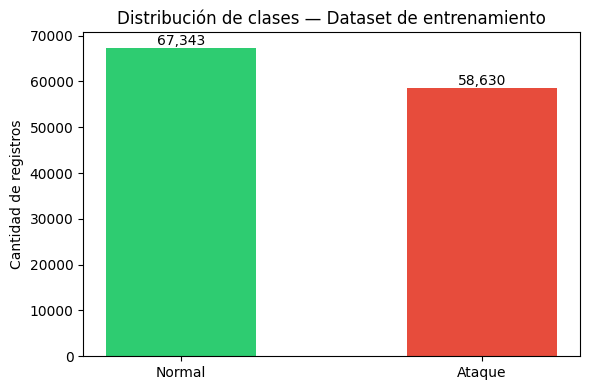

In [ ]:
# Distribución de clases: normal vs ataque
conteo = df_train['label_binario'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Normal', 'Ataque'], conteo.values, color=['#2ecc71', '#e74c3c'], width=0.5)
plt.title('Distribución de clases — Dataset de entrenamiento')
plt.ylabel('Cantidad de registros')
for i, v in enumerate(conteo.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


## 4. Hipótesis del Proyecto

**Hipótesis 1:** El tráfico de ataque tiene valores numéricos notablemente distintos al tráfico normal en variables como `src_bytes`, `duration` y `serror_rate`, lo que debería permitir a los modelos separar las dos clases con buena precisión.

**Hipótesis 2:** El tipo de protocolo y el servicio de red van a ser de las variables más importantes para detectar ataques, porque ciertos tipos de ataque siempre usan los mismos protocolos o apuntan a los mismos servicios.

**Hipótesis 3:** Un modelo simple como Regresión Logística ya va a dar resultados aceptables, pero Random Forest y KNN van a mejorar la detección de los ataques menos frecuentes como U2R y R2L.




## 5. Modelos Seleccionados

Para este proyecto se seleccionaron tres modelos de clasificación supervisada. Todos están disponibles en `scikit-learn`, son ampliamente usados en problemas de detección de intrusiones y permiten una comparación clara entre enfoques distintos.





### Modelo 1 — Regresión Logística

**Tipo de problema:** Clasificación binaria (normal / ataque)

**Justificación:** Es el modelo más simple de los tres y eso es exactamente por qué lo incluí. Sirve como punto de referencia o *baseline*: si los otros dos modelos no lo superan en rendimiento, hay algo mal en el proceso. Además, es fácil de interpretar porque sus coeficientes muestran directamente qué tan importante es cada variable para la predicción. Para un problema donde el tráfico normal y el de ataque son bastante diferentes en sus valores numéricos, la regresión logística debería dar resultados decentes sin mucho ajuste.





### Modelo 2 — Random Forest

**Tipo de problema:** Clasificación binaria (normal / ataque)

**Justificación:** Es un conjunto de árboles de decisión que trabajan en equipo y votan por la clase mayoritaria. Tiene varias ventajas para este dataset: maneja bien tanto variables numéricas como las que ya eran categóricas, no le afectan demasiado las variables irrelevantes porque los árboles las van descartando solos, y entrega un ranking de importancia de features que nos permite verificar la Hipótesis 2. Es el modelo que esperamos que tenga el mejor rendimiento general de los tres.





### Modelo 3 — K-Nearest Neighbors (KNN)

**Tipo de problema:** Clasificación binaria (normal / ataque)

**Justificación:** KNN clasifica una conexión mirando a las K conexiones más parecidas en el dataset de entrenamiento y asignando la clase que más se repite entre ellas. Es un enfoque completamente distinto a los otros dos y eso lo hace interesante para comparar. Su principal desventaja es que es más lento con datasets grandes porque calcula distancias para cada predicción, pero con el NSL-KDD es perfectamente manejable. También es sensible a la escala de las variables, por eso ya aplicamos `StandardScaler` en el paso anterior.


## 6. Tipo de problema

Los tres modelos resuelven un problema de **clasificación binaria supervisada**: dado un registro de tráfico de red, el modelo decide si pertenece a la clase **normal (0)** o **ataque (1)**. Se dice supervisado porque el dataset ya tiene las respuestas correctas etiquetadas, y binario porque solo hay dos posibles salidas.

In [ ]:
# Instanciamos los tres modelos
modelos = {
    'Regresion Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5)
}

print("Modelos listos para entrenar en el siguiente entregable:")
for nombre in modelos:
    print(f"  - {nombre}")


Modelos listos para entrenar en el siguiente entregable:
  - Regresion Logistica
  - Random Forest
  - KNN
